# Differentiating through a linear program

Companion to ORF522 Lecture 8 (duality II, sensitivity analysis).

We take the production problem of the lecture and turn it into a
"predict, then optimize" pipeline: a linear model predicts the profits
from market features, a linear program turns the predicted profits into
a production plan, and the plan is evaluated with the true profits.
Training the model end to end needs the derivative of the LP solution
with respect to its cost, which is where sensitivity analysis comes in.

In [1]:
import numpy as np
import cvxpy as cp
from scipy.optimize import linprog
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "text.usetex": True,  # comment out if LaTeX is not installed
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica Neue"],
        "font.size": 26,
        "figure.figsize": (9, 6.5),
    }
)
# Lecture palette (navy, wine, green, orange)
BLUE, RED, GREEN, ORANGE, BLACK = "#063b6d", "#800040", "#118040", "#cc6633", "#131313"

rng = np.random.default_rng(0)

## The production problem

Three products, three resources (material, production, quality control).
In standard form we minimize $c^T x$ with $c = -\text{profits}$ and
three slack variables.

In [2]:
A_res = np.array([[8, 6, 1], [4, 2, 1.5], [2, 1.5, 0.5]])
b = np.array([48.0, 20.0, 8.0])
A = np.hstack([A_res, np.eye(3)])  # standard form with slacks
m, n = A.shape
profits0 = np.array([60.0, 30.0, 20.0])


def solve_lp(c):
    """Solve min c^T x s.t. Ax = b, x >= 0. Returns x*."""
    res = linprog(c, A_eq=A, b_eq=b, bounds=(0, None), method="highs")
    return res.x


def to_cost(profits):
    """Profits of the three products -> cost vector of the standard form LP."""
    return np.concatenate([-np.asarray(profits), np.zeros(3)])


x_star = solve_lp(to_cost(profits0))
print("optimal plan", x_star[:3], "cost", to_cost(profits0) @ x_star)

optimal plan [2. 0. 8.] cost -280.0


## The catch: the LP solution is piecewise constant in $c$

Vary the profit of product 2 and watch the optimal plan. It does not move
until the profit reaches 35, which is 30 plus the reduced cost of product 2,
and then it jumps to another vertex. The derivative $\partial x^\star /
\partial c$ is zero almost everywhere and undefined at the jump.

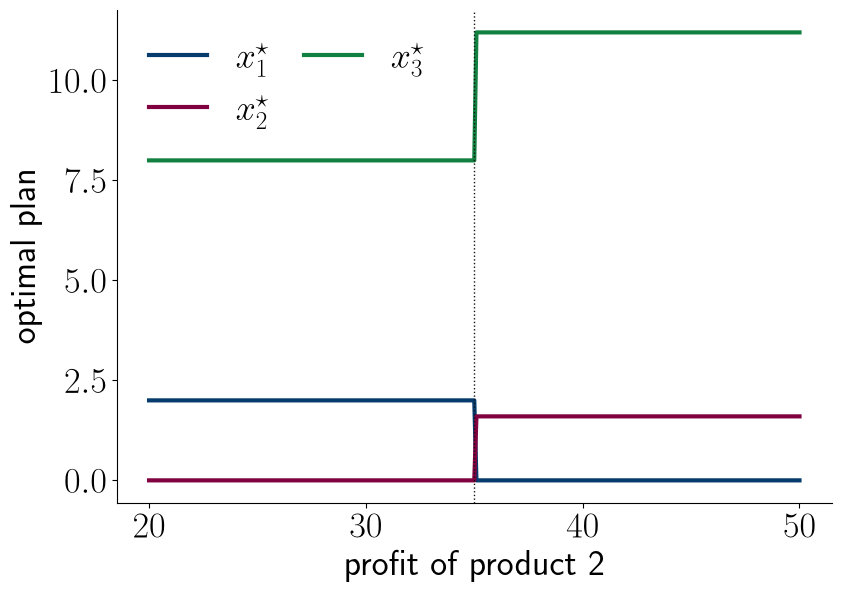

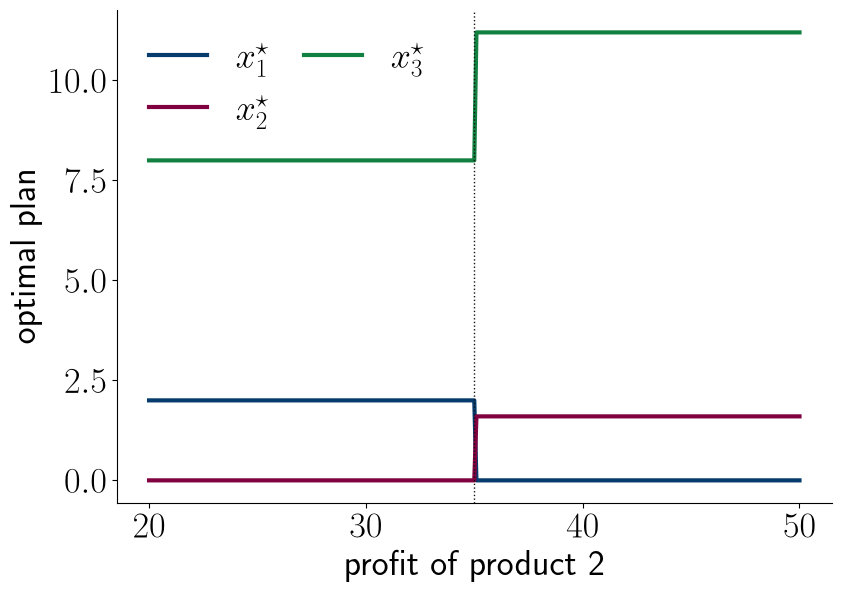

In [3]:
p2 = np.linspace(20, 50, 301)
plans = np.array([solve_lp(to_cost([60, p, 20]))[:3] for p in p2])


def plot_plans(plans_lp, plans_qp=None, fname=None):
    fig, ax = plt.subplots(figsize=(9, 6.5))
    colors = [BLUE, RED, GREEN]
    for i in range(3):
        ax.plot(p2, plans_lp[:, i], color=colors[i], lw=3, label=rf"$x_{i + 1}^\star$")
    if plans_qp is not None:
        for i in range(3):
            ax.plot(p2, plans_qp[:, i], color=colors[i], lw=3, ls="--")
        ax.plot([], [], color=BLACK, lw=3, ls="--", label=r"smoothed ($\gamma = 1$)")
    ax.axvline(35, color=BLACK, lw=1, ls=":")
    ax.set_xlabel(r"profit of product 2")
    ax.set_ylabel(r"optimal plan")
    ax.legend(loc="upper left", ncol=2, frameon=False, columnspacing=1.0, handlelength=1.6)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    if fname:
        fig.savefig(fname, transparent=True)
        fig.savefig(fname.replace(".svg", ".png"), dpi=60)
    return fig


plot_plans(plans, fname="lp-step.svg")

## The fix: change the loss (SPO+)

The regret $c^T x^\star(\hat c) - c^T x^\star(c)$ is what we care about,
but it is piecewise constant in $\hat c$. Elmachtoub and Grigas replace
it with a convex upper bound derived with LP duality,

$$\ell_{\rm SPO+}(\hat c, c) = \max_{x \in P}\,(c - 2\hat c)^T x + 2\hat c^T x^\star(c) - c^T x^\star(c),$$

whose gradient follows from $\partial p^\star/\partial c = x^\star$ and the chain rule, $2\,(x^\star(c) - x^\star(2\hat c - c))$: two LP solves
and no derivatives of the solver.

In [4]:
def regret(c_hat, c):
    return c @ solve_lp(c_hat) - c @ solve_lp(c)


def spo_plus_loss(c_hat, c):
    x_c = solve_lp(c)
    x_s = solve_lp(2 * c_hat - c)
    return (c - 2 * c_hat) @ x_s + 2 * c_hat @ x_c - c @ x_c


def spo_plus_grad(c_hat, c):
    """Gradient of the SPO+ loss with respect to the prediction c_hat."""
    return 2 * (solve_lp(c) - solve_lp(2 * c_hat - c))

## Predict, then optimize

Profits depend on $p = 4$ market features through a nonlinear map; the
model is linear (misspecified), as is common in practice. We compare

1. two-stage: least squares on the profits, then optimize,
2. SPO+: gradient descent on the SPO+ loss.

Both are scored by the test regret of the LP plan with the true profits.

In [5]:
p = 4
n_train, n_test = 200, 500
B_true = rng.standard_normal((3, p))


def true_profits(W):
    z = W @ B_true.T / np.sqrt(p)
    return profits0 * (1 + 0.6 * np.tanh(2 * z)) ** 3 / 1.5 * (1 + 0.1 * rng.standard_normal(z.shape))


W_train = rng.standard_normal((n_train, p))
W_test = rng.standard_normal((n_test, p))
P_train = true_profits(W_train)
P_test = true_profits(W_test)


def features(W):
    return np.hstack([W, np.ones((len(W), 1))])  # linear model with intercept


X_train, X_test = features(W_train), features(W_test)
C_train = np.array([to_cost(pr) for pr in P_train])
C_test = np.array([to_cost(pr) for pr in P_test])


def predict(Theta, X):
    """Theta maps features to predicted profits; returns predicted costs."""
    return np.array([to_cost(pr) for pr in X @ Theta.T])


def mean_regret(Theta, X, C):
    return np.mean([regret(ch, c) for ch, c in zip(predict(Theta, X), C)])

In [6]:
# 1. Two-stage least squares (closed form)
Theta_ls = np.linalg.lstsq(X_train, P_train, rcond=None)[0].T
regret_ls = mean_regret(Theta_ls, X_test, C_test)
print("two-stage least squares: test regret", regret_ls)

two-stage least squares: test regret 8.462844846916596


In [7]:
def train(grad_fn, epochs=40, lr=0.05, batch=20):
    """Stochastic gradient descent on Theta with a per-epoch test regret log."""
    Theta = Theta_ls.copy()  # warm start from least squares
    history = [mean_regret(Theta, X_test, C_test)]
    for _ in range(epochs):
        for idx in np.array_split(rng.permutation(n_train), n_train // batch):
            G = np.zeros_like(Theta)
            for i in idx:
                c_hat = to_cost(Theta @ X_train[i])
                g = grad_fn(c_hat, C_train[i])[:3]  # d loss / d predicted profits
                G += -np.outer(g, X_train[i]) / len(idx)  # cost = -profit
            Theta -= lr * G
        history.append(mean_regret(Theta, X_test, C_test))
    return Theta, np.array(history)

In [8]:
# 2. SPO+
Theta_spo, hist_spo = train(spo_plus_grad)
print("SPO+: test regret", hist_spo[-1])

SPO+: test regret 6.284086266394893


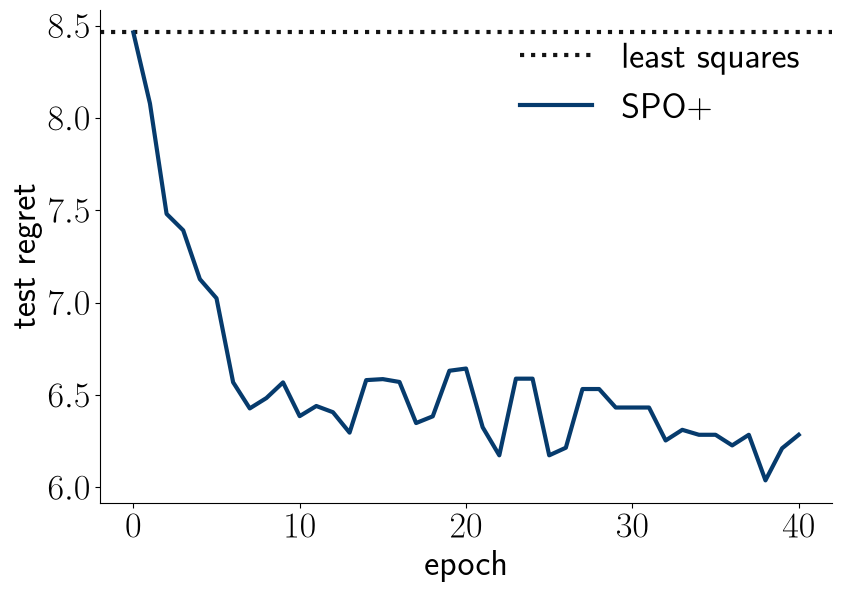

In [9]:
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.axhline(regret_ls, color=BLACK, lw=3, ls=":", label="least squares")
ax.plot(hist_spo, color=BLUE, lw=3, label="SPO+")
ax.set_xlabel("epoch")
ax.set_ylabel("test regret")
ax.legend(loc="upper right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("training-regret.svg", transparent=True)
fig.savefig("training-regret.png", dpi=60)

SPO+ beats the two-stage model on the decision that matters, even though
the two-stage model is the best predictor of the profits in the least
squares sense.

## Aside: smoothing the linear program instead

Another way to get a gradient is to change the problem rather than the
loss: add a small quadratic term so that the solution moves with $c$.
This is not covered in the lecture; the cells below show why it does not
help on this example.


### Quadratic smoothing

Add a small quadratic term, $\gamma/2\,\|x\|^2$, on the production
quantities. The solution of the resulting QP is unique and piecewise affine
in $c$, and its derivative follows from differentiating the optimality
conditions on the active constraints, exactly as in the local sensitivity
analysis of the lecture with the active set in place of the basis.

We write the feasible set as $P = \{x \mid Gx \le h\}$ with the three
resource constraints and the three bounds $x \ge 0$.

max |J - J_fd| = 5.073344084838283e-07


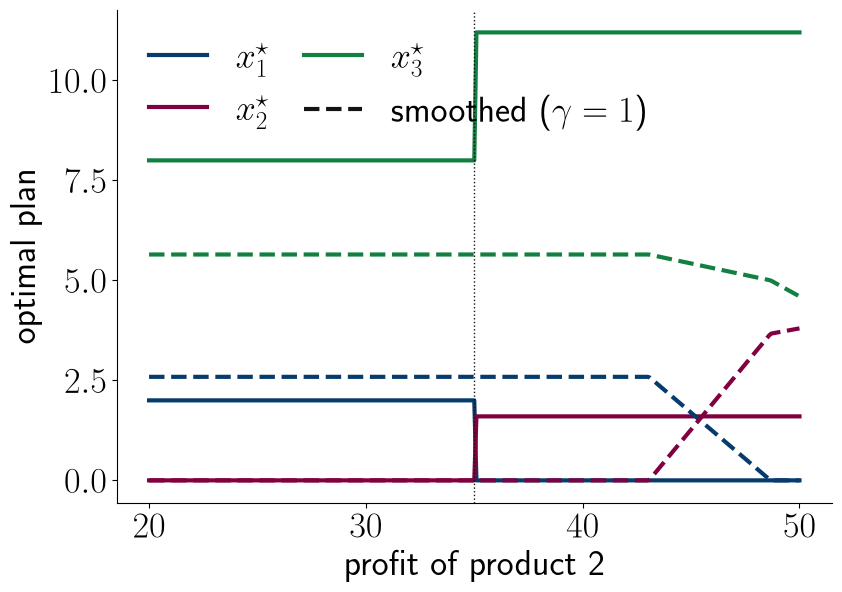

In [10]:
gamma = 1.0
G = np.vstack([A_res, -np.eye(3)])
h = np.concatenate([b, np.zeros(3)])
c_par = cp.Parameter(3)
x_var = cp.Variable(3)
qp = cp.Problem(
    cp.Minimize(c_par @ x_var + gamma / 2 * cp.sum_squares(x_var)),
    [G @ x_var <= h],
)


def solve_qp(c):
    """Solve min c^T x + gamma/2 ||x||^2 over P. Takes and returns the 3 products."""
    c_par.value = c[:3]
    qp.solve(solver=cp.CLARABEL)
    return x_var.value


def qp_solution_jacobian(c, tol=1e-6):
    """dx/dc of the smoothed problem by implicit differentiation.

    With S the active constraints (G_S x = h_S) the optimality conditions are
        gamma x + c + G_S^T lambda_S = 0,   G_S x = h_S.
    Differentiating with respect to c gives a linear system in
    (dx, dlambda_S) with right-hand side -I: the same computation as the
    local sensitivity analysis of the lecture, with the active set playing
    the role of the basis. At a vertex (three active constraints) dx = 0.
    """
    x = solve_qp(c)
    S = np.flatnonzero(h - G @ x < tol)
    G_S = G[S]
    K = np.block([[gamma * np.eye(3), G_S.T], [G_S, np.zeros((len(S), len(S)))]])
    rhs = np.vstack([-np.eye(3), np.zeros((len(S), 3))])
    sol = np.linalg.lstsq(K, rhs, rcond=None)[0]
    return x, sol[:3]  # 3 x 3 Jacobian of the products with respect to c[:3]


plans_qp = np.array([solve_qp(to_cost([60, p, 20])) for p in p2])
plot_plans(plans, plans_qp, fname="lp-step-smoothed.svg")

# Check the implicit derivative against finite differences
c0 = to_cost(profits0) + 0.1 * rng.standard_normal(n)
x0, J = qp_solution_jacobian(c0)
eps = 1e-5
J_fd = np.column_stack([(solve_qp(c0 + eps * e) - solve_qp(c0 - eps * e)) / (2 * eps) for e in np.eye(n)[:3]])
print("max |J - J_fd| =", np.abs(J - J_fd).max())

Training on the regret of the smoothed plan, with the implicit derivative
above, in place of the SPO+ gradient:

In [11]:
def smoothed_regret_grad(c_hat, c):
    _, J = qp_solution_jacobian(c_hat)
    return np.concatenate([J.T @ c[:3], np.zeros(3)])


Theta_qp, hist_qp = train(smoothed_regret_grad, lr=0.003)
print("smoothed QP: test regret", hist_qp[-1])

smoothed QP: test regret 8.557119758847604


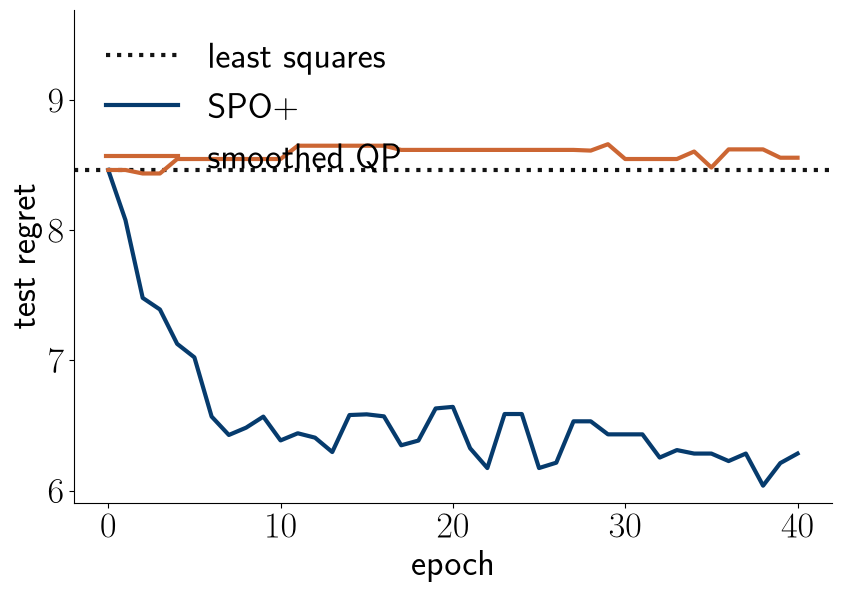

In [12]:
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.axhline(regret_ls, color=BLACK, lw=3, ls=":", label="least squares")
ax.plot(hist_spo, color=BLUE, lw=3, label="SPO+")
ax.plot(hist_qp, color=ORANGE, lw=3, label="smoothed QP")
ax.set_xlabel("epoch")
ax.set_ylabel("test regret")
ax.set_ylim(top=ax.get_ylim()[1] + 0.9)
ax.legend(loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("training-regret-smoothed.svg", transparent=True)

The smoothed QP does not improve on least squares here, for any $\gamma$
and step size we tried. Its plan is biased toward the interior of $P$ (the
quadratic shrinks the quantities), so the smoothed solution leaves the
vertex only well past the profit at which the LP switches plans (compare
the ramps in the plot above with the jump at 35). The gradient of
$c^T x_\gamma(\hat c)$ therefore points to predictions that are good for the
smoothed plan, not for the vertex the LP picks. Smaller $\gamma$ moves the
ramps toward the true switch but makes them so narrow that almost no
training sample gives a gradient.